In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

if not torch.cuda.is_available():
    raise ValueError("GPU not found, code will run on CPU and can be extremely slow!")
else:
    device = torch.device("cuda:0")

import time
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping
import torch.optim as optim
import torch.utils.data as dt


import os
os.chdir('/mnt/c/Users/ankit/Desktop/Msc AIML/msc-project/GAP/gap')
from GAP_UNET_ResBlock_ffhq_super_res import UN
from BinomDataset_ffhq_super_res import BinomDataset
from DataFolderFFHQ import DataFolder
from inferencev3 import sample_image
from tasks import inpainting
from utils import preprocess, stats, stack_video

In [3]:
name = 'm40to30-256x256-ffhq-super-res-8-64'
# name = 'm40to30-256x256-ffhq-run-2'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/'

model = UN(channels = 3, levels=10, depth=6,start_filts=32, 
           up_mode = 'upsample', merge_mode = 'concat').to(device)
model = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

(-0.5, 511.5, 511.5, -0.5)

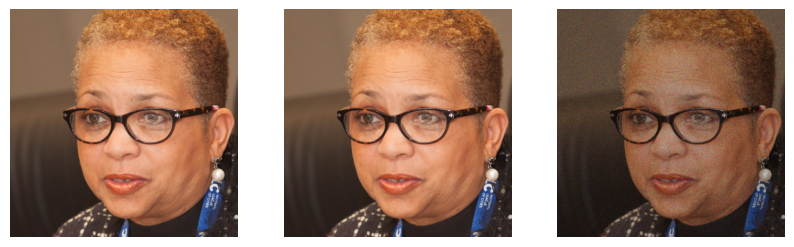

In [5]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/'
dataset = DataFolder(ffhq_path, minPSNR = -40, maxPSNR= 20, virtSize= 1)
dataTestGT, dataTestTarget, dataTest = dataset[491]
plt.figure(figsize= (10, 10))
vmax = np.percentile(dataTestGT, 99.9)
plt.subplot(1, 3, 1)
plt.imshow(preprocess(dataTestGT), vmin = 0, vmax = vmax)
plt.axis('off')
vmax = np.percentile(dataTestTarget, 99.9)
plt.subplot(1, 3, 2)
plt.imshow(preprocess(dataTestTarget), vmin = 0, vmax = vmax, cmap= 'gray')
plt.axis('off')
vmax = np.percentile(dataTest, 99.9)
plt.subplot(1, 3, 3)
plt.imshow(preprocess(dataTest), vmin = 0, vmax = vmax)
plt.axis('off')

In [8]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/faces/'
minpsnr = -40
maxpsnr = 30
dataset = BinomDataset(ffhq_path, windowSize = 256, minPSNR = minpsnr, maxPSNR= maxpsnr, virtSize= 1, in_size= 8, out_size= 64)

(-0.5, 63.5, 63.5, -0.5)

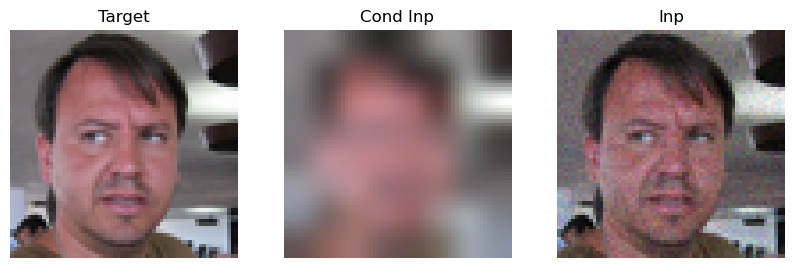

In [13]:
channels = 3
img = dataset[5000000000]
plt.figure(figsize= (10, 10))
plt.subplot(1, 3, 1)
plt.imshow(preprocess(img[:channels]))
plt.title('Target')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(preprocess(img[channels:channels + channels]))
plt.title('Cond Inp')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(preprocess(img[channels + channels:channels  + channels + channels]), vmin = 0, vmax = 255)
plt.title('Inp')
plt.axis('off')

(-0.5, 511.5, 511.5, -0.5)

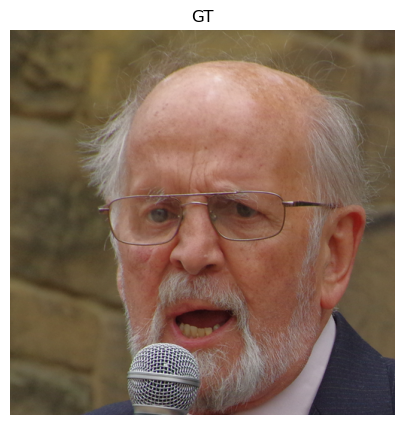

In [86]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/'
dataset = DataFolder(ffhq_path, minPSNR = -20, maxPSNR= 0)
dataTestGT, dataTestTarget, dataTest = dataset[12455]
plt.figure(figsize= (5, 5))
vmax = np.percentile(dataTestGT, 99.9)
# plt.subplot(1, 3, 1)
# plt.imshow(preprocess(dataTestGT), vmin = 0, vmax = vmax)
# plt.axis('off')
vmax = np.percentile(dataTestTarget, 99.9)
# plt.subplot(1, 3, 2)
plt.imshow(preprocess(dataTestTarget), vmin = 0, vmax = vmax)
plt.title('GT')
plt.axis('off')
# vmax = np.percentile(dataTest, 99.9)
# plt.subplot(1, 3, 3)
# plt.imshow(preprocess(dataTest), vmin = 0, vmax = vmax)
# plt.axis('off')

In [70]:
from torchvision import transforms
from PIL import Image
def convert2lr8(img):
    lr = transforms.functional.resize(img = img, size = 8, interpolation = Image.BICUBIC, antialias = True)
    lr = transforms.functional.center_crop(img  = lr, output_size = 8)
    sr = transforms.functional.resize(img = lr, size = 64, interpolation = Image.BICUBIC, antialias = True)
    return sr

def convert2lr64(img):
    lr = transforms.functional.resize(img = img, size = 64, interpolation = Image.BICUBIC, antialias = True)
    lr = transforms.functional.center_crop(img  = lr, output_size = 64)
    sr = transforms.functional.resize(img = lr, size = 512, interpolation = Image.BICUBIC, antialias = True)
    return sr

def resize(img):
    img = transforms.functional.resize(img = img, size = 64, interpolation = Image.BICUBIC, antialias = True)
    img = img - img.min()
    img = torch.from_numpy(img.numpy().astype(np.int32))
    return img

def resize2hr(img):
    img = transforms.functional.resize(img = img, size = 512, interpolation = Image.BICUBIC, antialias = True)
    img = img - img.min()
    img = torch.from_numpy(img.numpy())
    return img

(-0.5, 63.5, 63.5, -0.5)

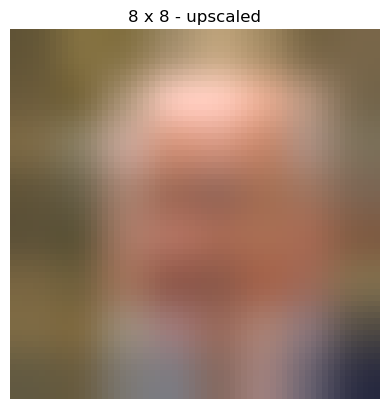

In [87]:
# dataTestGT = resize(dataTestGT)
cond_inp = convert2lr8(dataTestGT)
cond_inp = cond_inp/(cond_inp.mean()+ 1e-8)
plt.imshow(preprocess(cond_inp))
plt.title('8 x 8 - upscaled')
plt.axis('off')

In [69]:
dataTestGT.shape

torch.Size([3, 64, 64])

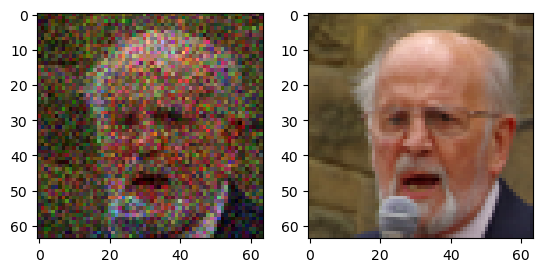

In [88]:
from PSNRSample import PSNRSample
psnr = PSNRSample(minPSNR= -40, maxPSNR= 30)
dataTestGT = resize(dataTestGT).to(torch.float)
dataTest = psnr.sample(dataTestGT, 0.7)
testGT = dataTestGT/dataTestGT.mean()
cond_test = testGT 
plt.subplot(1, 2, 1)
plt.imshow(preprocess(dataTest))
plt.subplot(1, 2, 2)
plt.imshow(preprocess(cond_test))

torch.Size([3, 64, 64])
torch.Size([1, 3, 64, 64])
torch.Size([3, 64, 64])
input shape : torch.Size([1, 6, 64, 64]), model input shape : torch.Size([1, 1, 6, 64, 64])
tensor(210.) tensor(0.) tensor(36.1091) 202.71300000000156 77.0
inp shape : torch.Size([3, 64, 64])
out shape : torch.Size([1, 3, 64, 64])
gt shape : torch.Size([3, 64, 64])


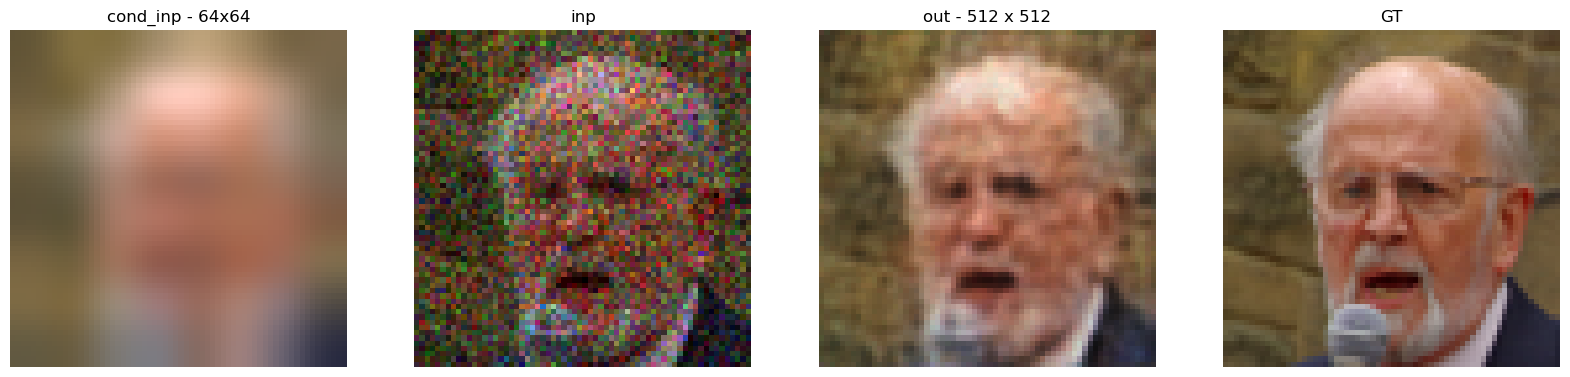

In [89]:
cond_input = cond_inp[None]
# cond_input = torch.from_numpy(np.zeros_like(cond_input))
for inp, cinp, gt in zip(dataTest[None], cond_input[None], dataTestGT[None]): 
    print(inp.shape) 
    print(cinp.shape) 
    print(gt.shape) 

    inpT = inp.to(device) 
    cond_inpT = cinp.to(device)
    inpT = torch.cat([cond_inpT, inpT[None]], dim = 1).to(device)
    print(f'input shape : {inpT.shape}, model input shape : {inpT[None].shape}')
    out = torch.exp(model(inpT).detach().cpu())
    out = inp.sum() * out / out.sum() 
    
    print(gt.max(), gt.min(), gt.std(), np.percentile(gt,99.9), np.percentile(gt,50))

    inp = inp/inp.mean()
    out = out/out.mean()
    gt = gt/gt.mean()
    # cond_inp = cinp[1]/cinp[1].mean()

    
    print(f'inp shape : {inp.shape}')
    print(f'out shape : {out.shape}')
    print(f'gt shape : {gt.shape}')

    cond_vmax = np.percentile(preprocess(cond_input[0]),99.9)
    plt.figure(figsize=(20,20))
    plt.subplot(1, 4, 1)
    plt.imshow(preprocess(cond_input[0]) ,vmin = 0, vmax = cond_vmax, cmap = 'gray')
    plt.title('cond_inp - 64x64')
    plt.axis('off')

    vmax = np.percentile(preprocess(gt),99.9)
    plt.subplot(1, 4, 2)
    plt.imshow(preprocess(inp),vmin = 0, vmax = vmax)
    plt.title('inp')
    # plt.show()
    plt.axis('off')
    vmax = np.percentile(preprocess(gt),99.9)
    plt.subplot(1, 4, 3)
    plt.imshow(preprocess(out[0]),vmin = 0,vmax = vmax)
    plt.title('out - 512 x 512')
    # plt.show()
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(preprocess(gt),vmin = 0,vmax = vmax)
    plt.title('GT')
    plt.axis('off')
    plt.show()
    


In [55]:
out.shape

torch.Size([1, 3, 64, 64])

In [53]:
name = 'm40to30-256x256-ffhq-super-res'
# name = 'm40to30-256x256-ffhq-run-2'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/'

model2 = UN(channels = 3, levels=10, depth=6,start_filts=32, 
           up_mode = 'upsample', merge_mode = 'concat').to(device)
model2 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

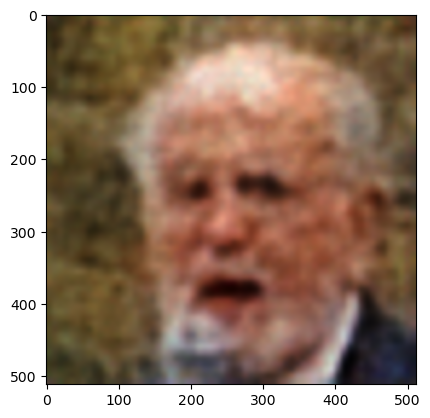

In [90]:
cond_inp = resize2hr(out[0])
plt.imshow(preprocess(cond_inp))

(-0.5, 511.5, 511.5, -0.5)

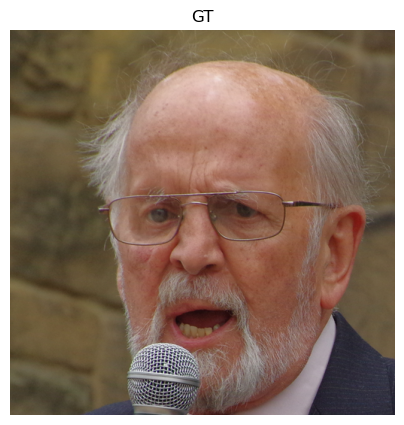

In [91]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/'
dataset = DataFolder(ffhq_path, minPSNR = -20, maxPSNR= 0)
dataTestGT, dataTestTarget, dataTest = dataset[12455]
plt.figure(figsize= (5, 5))
vmax = np.percentile(dataTestGT, 99.9)

vmax = np.percentile(dataTestTarget, 99.9)
# plt.subplot(1, 3, 2)
plt.imshow(preprocess(dataTestTarget), vmin = 0, vmax = vmax)
plt.title('GT')
plt.axis('off')


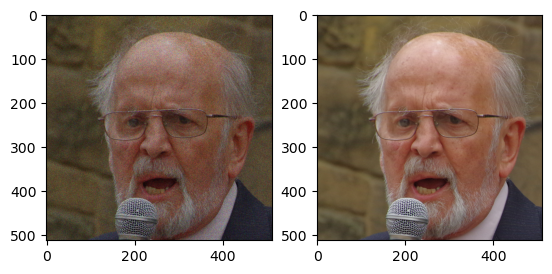

In [92]:
from PSNRSample import PSNRSample
psnr = PSNRSample(minPSNR= -40, maxPSNR= 30)
dataTest = psnr.sample(dataTestGT, 0.8)
testGT = dataTestGT/dataTestGT.mean()
cond_test = testGT 
plt.subplot(1, 2, 1)
plt.imshow(preprocess(dataTest))
plt.subplot(1, 2, 2)
plt.imshow(preprocess(cond_test))

torch.Size([3, 512, 512])
torch.Size([1, 3, 512, 512])
torch.Size([3, 512, 512])
input shape : torch.Size([1, 6, 512, 512]), model input shape : torch.Size([1, 1, 6, 512, 512])
tensor(244.) tensor(0.) tensor(37.6828) 220.0 91.0
inp shape : torch.Size([3, 512, 512])
out shape : torch.Size([1, 3, 512, 512])
gt shape : torch.Size([3, 512, 512])


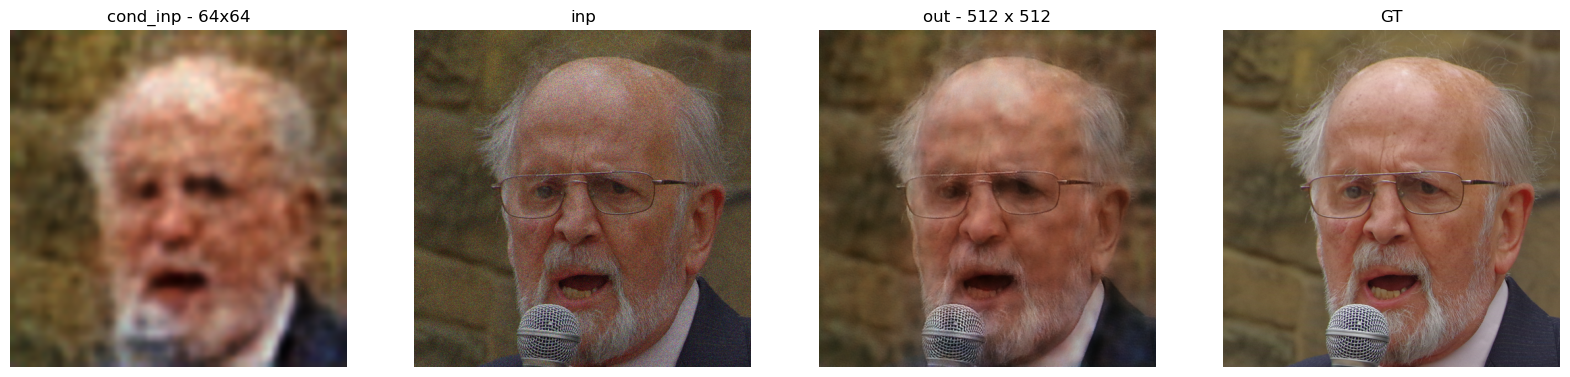

In [93]:
cond_input = cond_inp[None]
# cond_input = torch.from_numpy(np.zeros_like(cond_input))
for inp, cinp, gt in zip(dataTest[None], cond_input[None], dataTestGT[None]): 
    print(inp.shape) 
    print(cinp.shape) 
    print(gt.shape) 

    inpT = inp.to(device) 
    cond_inpT = cinp.to(device)
    inpT = torch.cat([cond_inpT, inpT[None]], dim = 1).to(device)
    print(f'input shape : {inpT.shape}, model input shape : {inpT[None].shape}')
    out = torch.exp(model2(inpT).detach().cpu())
    out = inp.sum() * out / out.sum() 
    
    print(gt.max(), gt.min(), gt.std(), np.percentile(gt,99.9), np.percentile(gt,50))

    inp = inp/inp.mean()
    out = out/out.mean()
    gt = gt/gt.mean()
    # cond_inp = cinp[1]/cinp[1].mean()

    
    print(f'inp shape : {inp.shape}')
    print(f'out shape : {out.shape}')
    print(f'gt shape : {gt.shape}')

    cond_vmax = np.percentile(preprocess(cond_input[0]),99.9)
    plt.figure(figsize=(20,20))
    plt.subplot(1, 4, 1)
    plt.imshow(preprocess(cond_input[0]) ,vmin = 0, vmax = cond_vmax, cmap = 'gray')
    plt.title('cond_inp - 64x64')
    plt.axis('off')

    vmax = np.percentile(preprocess(gt),99.9)
    plt.subplot(1, 4, 2)
    plt.imshow(preprocess(inp),vmin = 0, vmax = vmax)
    plt.title('inp')
    # plt.show()
    plt.axis('off')
    vmax = np.percentile(preprocess(gt),99.9)
    plt.subplot(1, 4, 3)
    plt.imshow(preprocess(out[0]),vmin = 0,vmax = vmax)
    plt.title('out - 512 x 512')
    # plt.show()
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(preprocess(gt),vmin = 0,vmax = vmax)
    plt.title('GT')
    plt.axis('off')
    plt.show()
    
